In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import glob
import numpy as np
from glob import glob
from itertools import compress
from matplotlib.dates import DateFormatter
import matplotlib.dates as mdates

In [2]:
ds_dp_scream = xr.open_dataset(
      "/data/project/ARM_Summer_School_2026/data/modeling/dpscream/"
      "scream_dpxx_LASSO_SGP_2018-07-09.fullfield.AVERAGE.nhours_x1.2018-07-09-43200.nc"
  )

x = np.unique(ds_dp_scream.lon.values)   # 10 values: 2500, 7500, ..., 47500 m
y = np.unique(ds_dp_scream.lat.values)   # same

cf_colmax = ds_dp_scream['cldfrac_tot'].max(dim='lev')   # (time, ncol)

cf_scream = xr.DataArray(
  cf_colmax.values.reshape(ds_dp_scream.sizes['time'], len(y), len(x)),
  dims=['time', 'y', 'x'],
  coords={
      'time': ds_dp_scream.time,
      'y': y,
      'x': x,
  },
  attrs={'units': '1', 'long_name': 'Column-max total cloud fraction'},
)

ERROR 1: PROJ: proj_create_from_database: Open of /opt/conda/share/proj failed


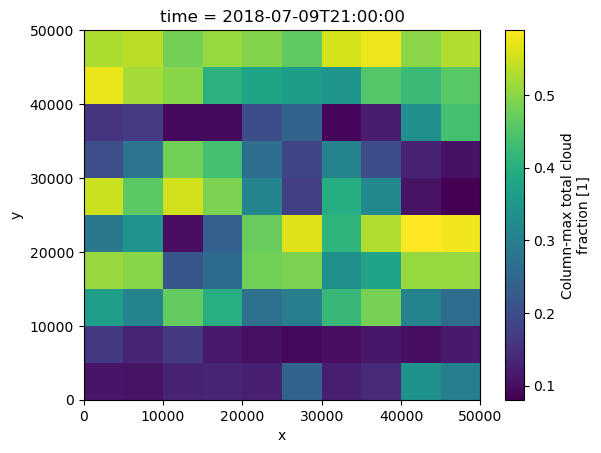

In [3]:
cf_scream.isel(time = 8).plot()